In [47]:
# IMPORT LIBRARY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [48]:
# LOAD DATA

print("=== LOAD DATA ===")
df = pd.read_csv('creditcard.csv')

print("Shape data:", df.shape)
print("\nInfo data:")
print(df.info())


=== LOAD DATA ===
Shape data: (284807, 31)

Info data:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20 

In [49]:
# EDA (EXPLORATORY DATA ANALYSIS)

print("\n=== EDA ===")

# Missing values
missing_values = df.isnull().sum()
print("\nMissing Values:\n", missing_values)
print("Total Missing:", missing_values.sum())

# Duplicate
duplicate_count = df.duplicated().sum()
print("\nJumlah Duplikasi:", duplicate_count)

# Statistik
print("\nStatistik Deskriptif:")
print(df.describe())



=== EDA ===

Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Total Missing: 0

Jumlah Duplikasi: 1081

Statistik Deskriptif:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.54


=== VISUALISASI AWAL ===


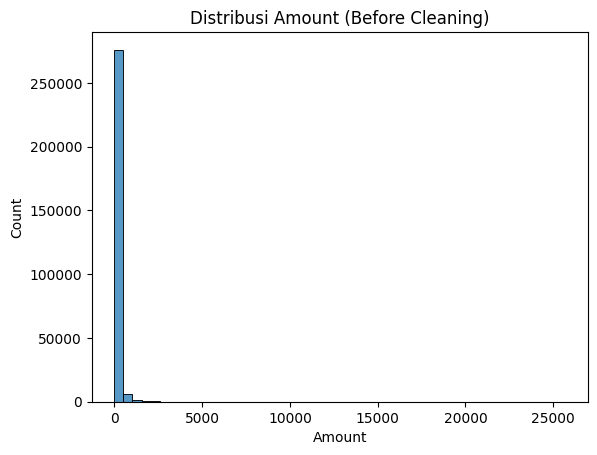

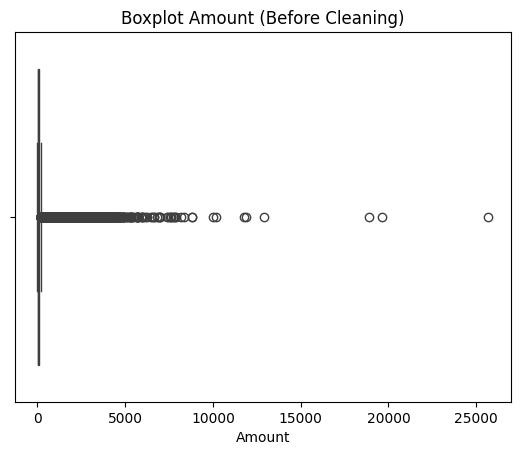

In [50]:
# VISUALISASI AWAL

print("\n=== VISUALISASI AWAL ===")

plt.figure()
sns.histplot(df['Amount'], bins=50)
plt.title("Distribusi Amount (Before Cleaning)")
plt.show()

# Boxplot (Outlier)
plt.figure()
sns.boxplot(x=df['Amount'])
plt.title("Boxplot Amount (Before Cleaning)")
plt.show()



In [51]:
# DATA CLEANING

print("\n=== DATA CLEANING ===")

# Hapus duplikasi
print("Sebelum hapus duplikasi:", df.shape)
df = df.drop_duplicates()
print("Setelah hapus duplikasi:", df.shape)



=== DATA CLEANING ===
Sebelum hapus duplikasi: (284807, 31)
Setelah hapus duplikasi: (283726, 31)


In [52]:
# HANDLE OUTLIER (IQR)

print("\n=== HANDLE OUTLIER (IQR) ===")

Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Amount'] >= lower_bound) & (df['Amount'] <= upper_bound)]

print("Setelah hapus outlier:", df.shape)



=== HANDLE OUTLIER (IQR) ===
Setelah hapus outlier: (252041, 31)


In [53]:
# PREPROCESSING

print("\n=== PREPROCESSING ===")

scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Drop kolom lama
df = df.drop(['Amount', 'Time'], axis=1)

print("Preprocessing selesai")


=== PREPROCESSING ===
Preprocessing selesai



=== VISUALISASI SETELAH PREPROCESSING ===


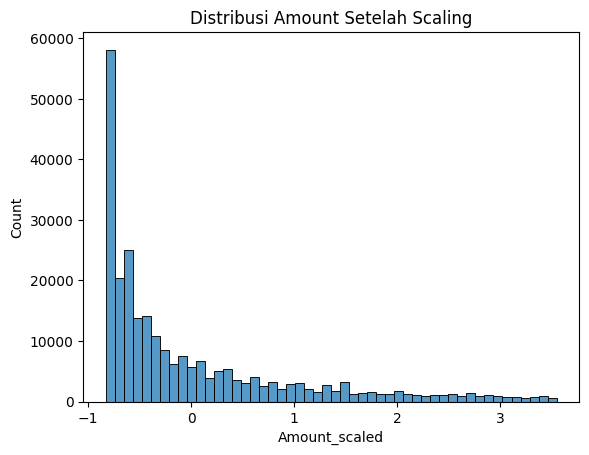

In [54]:
# VISUALISASI SETELAH PREPROCESSING

print("\n=== VISUALISASI SETELAH PREPROCESSING ===")

# Histogram setelah scaling
plt.figure()
sns.histplot(df['Amount_scaled'], bins=50)
plt.title("Distribusi Amount Setelah Scaling")
plt.show()


=== HEATMAP ===


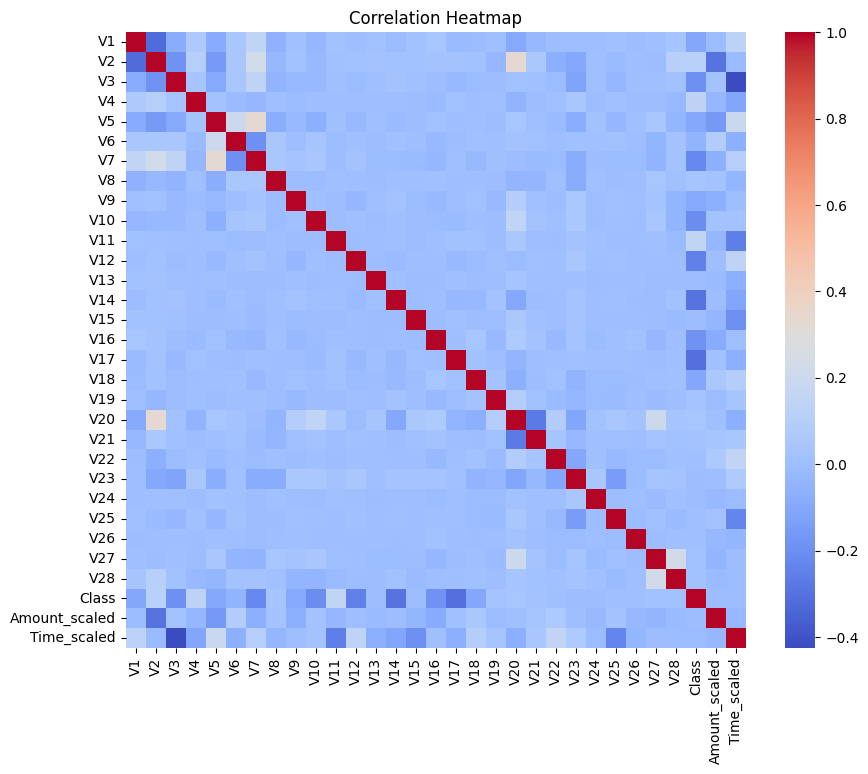

In [55]:
# HEATMAP KORELASI

print("\n=== HEATMAP ===")

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


=== DISTRIBUSI CLASS ===


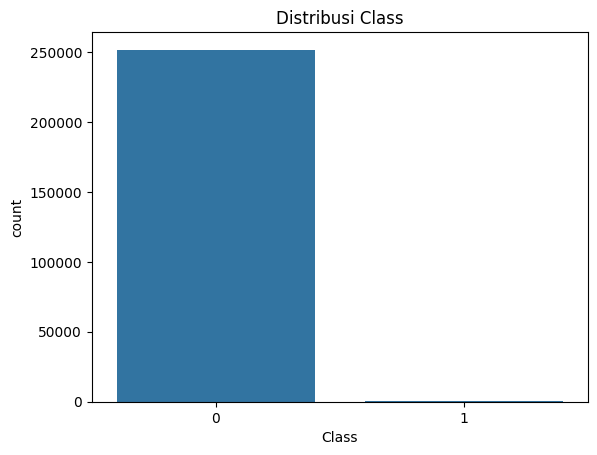

In [56]:
# DISTRIBUSI TARGET

print("\n=== DISTRIBUSI CLASS ===")

plt.figure()
sns.countplot(x='Class', data=df)
plt.title("Distribusi Class")
plt.show()

In [57]:
# OUTPUT AKHIR

print("\n=== DATA SIAP DIGUNAKAN ===")
print("Shape akhir:", df.shape)
print(df.head())


=== DATA SIAP DIGUNAKAN ===
Shape akhir: (252041, 31)
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   
5 -0.425966  0.960523  1.141109 -0.168252  0.420987 -0.029728  0.476201   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   
5  0.260314 -0.568671 -0.371407  ... -0.559825 -0.026398 -0.371427 -0.232794   

        V26  